In [1]:
import requests
from train_embeddings import WordDataSet
import sys
from pathlib import Path

# For Jupyter notebooks, use os.getcwd() or hardcode the path
notebook_dir = Path.cwd()  # Gets current working directory
src_dir = notebook_dir.parent if notebook_dir.name == 'embeddings' else notebook_dir / 'src'
sys.path.append(str(src_dir))
from tokenization import SBTokenizer



In [2]:
def get_data():
    resp = requests.get("https://www.gutenberg.org/files/35/35-0.txt")
    return resp.text

txt = get_data()

In [3]:
tokzer = SBTokenizer()
tokzer.train(txt, vocab_size=10000)

We are done at  9595


In [4]:
print(len(tokzer.vocab))

9851


In [5]:
context_length = 8
# data_set = WordDataSet(t, "His pale grey eyes shone and twinkled, and his usually pale face was flushed and animated", context_len=5, stride=3)
data_set = WordDataSet(tokzer, txt, context_length, stride=4)

print(len(data_set))

9779


In [6]:
print(data_set.inputs[:1])
print(data_set.targets[:1])

[tensor([2539, 5314, 3748, 3750, 3756, 3762, 3766, 3768])]
[tensor([5314, 3748, 3750, 3756, 3762, 3766, 3768, 3769])]


In [8]:
from torch.utils.data import DataLoader
import torch

dl = DataLoader(data_set, batch_size=32, shuffle=True, drop_last=True)

for k, (i,tg) in enumerate(dl):
    print("Input => ", tokzer.decode(i[0].detach().tolist()))
    print("Traget => ", tokzer.decode(tg[0].detach().tolist()))
    
    # for k, (it,tg) in enumerate(it):
    #     print(it)
    #     print(tg)
    #     # print("Input => ", t.decode(it.detach().tolist()))
    #     # print("Traget => ", t.decode(tg.detach().tolist()))
    print("\n")
    print("Input => ", tokzer.decode(i[1].detach().tolist()))
    print("Traget => ", tokzer.decode(tg[1].detach().tolist()))
    # print(t.decode(j[1].detach().tolist()))
    break

print(len(dl.dataset))

Input =>   marrow, and the pain I felt
Traget =>  arrow, and the pain I felt in


Input =>   where did the dream come from? …
Traget =>   did the dream come from? … I
9779


In [8]:
import torch
a = torch.tensor( [1,3,4,6])
r = a.exp() / a.exp().sum()
print(r)

b = a - 6
print(b)
r1 = b.exp() / b.exp().sum()
print(r1)

tensor([0.0057, 0.0418, 0.1135, 0.8390])
tensor([-5, -3, -2,  0])
tensor([0.0057, 0.0418, 0.1135, 0.8390])


* Train the embedding now

In [9]:
from torchinfo import summary
from train_embeddings import EmbeddingModel

In [10]:
# class EmbeddingModel(nn.Module):
#     def __init__(self, vocab_size, embedding_dim, context_size, layer1_out=128): # context_size or block_size or sequence_len
#         print("CS = ", context_size)
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embedding_dim)
#         print("Embedding shape = ", self.embedding.weight.shape)
        

#         # init the layers
#         self.linear1 = nn.Linear(context_size * embedding_dim, layer1_out)
#         self.linear2 = nn.Linear(layer1_out, vocab_size)
#         self.apply(EmbeddingModel.init_weights)

#     def init_weights(layer):
#         # scale the the weights, we generally don't do it for embedding layer
#         if isinstance(layer, nn.Linear):
#             print("In init weights applying for ", layer)
#             # Generally Kaiming for ReLU or Xavier for Tanh/Sigmoid, but are following the lecture here
#             nn.init.xavier_normal_(layer.weight)
#             if layer.bias is not None:
#                 nn.init.zeros_(layer.bias)
       
    
#     def forward(self, inputs): #(batch_size, context_size)
#         # get embeddings for the inputs
#         emb = self.embedding(inputs) # (batch_size, context_size, embedding_dim)
#         print("Emb sape = ", emb.shape)
#         # flatten the embeddings
#         emb = emb.view(inputs.shape[0], -1) #(batch_size, context_size * embedding_dim)
#         print("Emb sape after view = ", emb.shape)
#         # pass through linear layers
#         h = F.relu(self.linear1(emb))
#         print("Layer 1 out shape= ", h.shape)
        
#         out = self.linear2(h)
#         print("Layer 2 out shape= ", out.shape)

#         # softmax log probs
#         # soft_max probs = e^out/sum(e^out)
#         # log_soft_max = log(soft_max)
#         # n_log_soft_max = -log_soft_max
#         # loss = n_log_soft_max[ipd_idx].mean()

#         log_sf = F.log_softmax(out, dim=1)

#         return log_sf
        

In [10]:
# Set up device for Mac GPU (MPS)
import torch

# Check if MPS is available
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Mac GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device is  {device}")

Using MPS (Mac GPU)
Device is  mps


In [11]:
vocab_size = len(tokzer.vocab)
print("Vocab size = ", vocab_size)
embedding_dim = 128

model = EmbeddingModel(vocab_size, embedding_dim, context_length, device=device)
print(summary(model))
parms = sum([p.nelement() for p in model.parameters()])

pre_train_embs = model.embedding.weight.detach().cpu().clone()

Vocab size =  9851
CS =  8
Embedding shape =  torch.Size([9851, 128])
In init weights applying for  Embedding(9851, 128)
In init weights applying for  Linear(in_features=1024, out_features=128, bias=True)
In init weights applying for  Linear(in_features=128, out_features=9851, bias=True)
Layer (type:depth-idx)                   Param #
EmbeddingModel                           --
├─Embedding: 1-1                         1,260,928
├─Linear: 1-2                            131,200
├─Linear: 1-3                            1,270,779
Total params: 2,662,907
Trainable params: 2,662,907
Non-trainable params: 0


In [13]:
optimizerAW = torch.optim.AdamW(model.parameters(), lr = 0.001, weight_decay=0.01)
optimizerSGD = torch.optim.SGD(model.parameters(), lr = 0.01, momentum=0.9)
loss_fn = torch.nn.NLLLoss().to(device)
model.traiModel(dl, num_epochs=50, loss_function=loss_fn, optimizer=optimizerAW)
post_train_embs = model.embedding.weight.detach().cpu().clone()

In [14]:
# Evaluate model on GPU
data_loder_itr = iter(dl)
xx = 0
it, tar = next(data_loder_itr)
it = it.to(device)
x = it[0]
xd = x.detach().tolist()
start = x.unsqueeze(0)
print(start)
print(start.shape)
start_txt = tokzer.decode(xd)
print("Start text => ", start_txt)

gen_len = 100

for i in range(gen_len):
    out = model(start)
    out = torch.exp(out)
    # print(out.shape)
    # start_txt += tokzer.decode([out.argmax(dim=1).item()])
    start_txt += tokzer.decode([torch.multinomial(out, num_samples=1).item()])
    stripped = start[:, 1:]
    # print("Stripped => ", stripped)
    start = torch.cat([stripped, out.argmax(dim=1).unsqueeze(0)], dim=1)
    # print("NS => ", start)

print("Gen text => ", start_txt)

tensor([[  13,  269,  489,  399, 1642,  260,  653,  394]], device='mps:0')
torch.Size([1, 8])
Start text =>  . I could not imagine the Morlocks were
Gen text =>  . I could not imagine the Morlocks were strong. And this last as both as put as I saw about that heart, but she had aated on fast I drew sure this bar of it under all. I was a block. dreaming?” some jumping the floor crest!or B agreed squat to lost creeping of the end. “ big is their half lay me. all was in his dark, and four through the world in a shadows round—half how he was shadow me exactly! And that I proceeded doing the soft us, and all


In [15]:
ffg = torch.tensor([[1,4,5,6]])
dff = torch.tensor([[11]])
ffg[:, 1:]
fl = torch.cat([ffg[:, 1:], dff], dim=1)
print(fl, fl.shape)

tensor([[ 4,  5,  6, 11]]) torch.Size([1, 4])


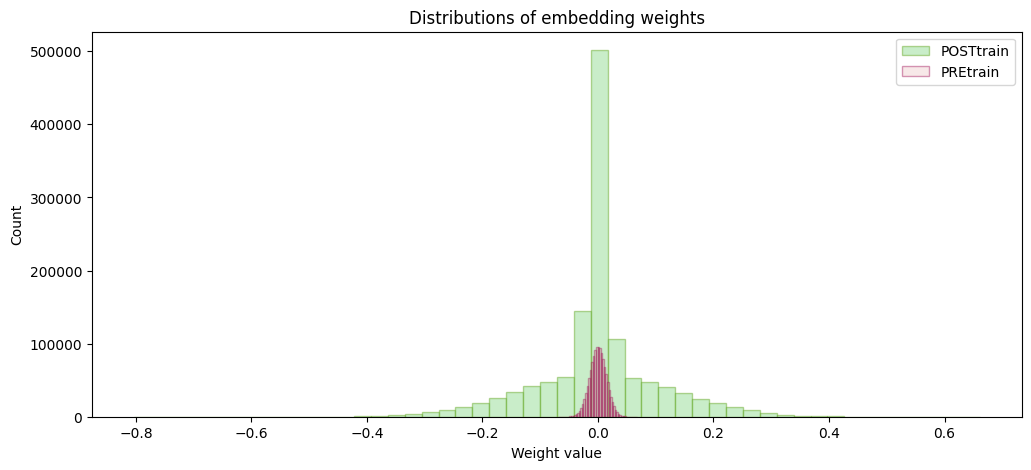

In [15]:
import matplotlib.pyplot as plt
import numpy as np


# histograms via numpy
yPre,xPre = np.histogram(pre_train_embs.flatten(),bins=50)
yPst,xPst = np.histogram(post_train_embs.flatten(),bins=50)

# recalculate x values as bin centers
xPre = (xPre[1:]+xPre[:-1]) / 2
xPst = (xPst[1:]+xPst[:-1]) / 2

# and plot
plt.figure(figsize=(12,5))
plt.bar(xPst,yPst,width=xPst[1]-xPst[0],color=[.7,.9,.7,.7],edgecolor=[.3,.6,0,.4],label='POSTtrain')
plt.bar(xPre,yPre,width=xPre[1]-xPre[0],color=[.9,.7,.7,.3],edgecolor=[.6,0,.3,.4],label='PREtrain')

plt.gca().set(xlabel='Weight value',ylabel='Count',title='Distributions of embedding weights')
plt.legend()
plt.show()

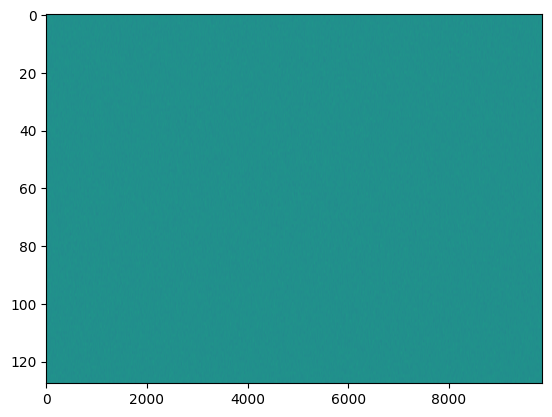

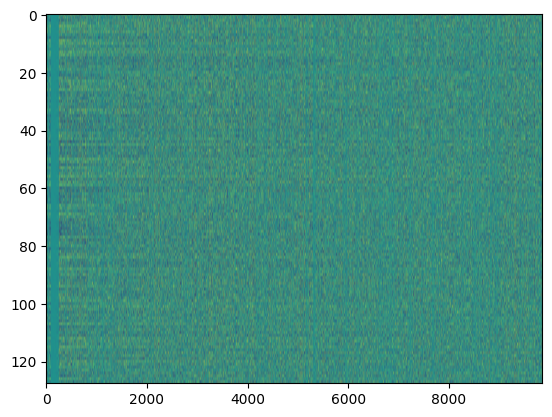

In [16]:
# inspect embeddigs
import matplotlib.pyplot as plt


plt.imshow(pre_train_embs.T, aspect='auto', vmin=-0.2, vmax=0.2)
plt.show()

plt.imshow(post_train_embs.T, aspect='auto', vmin=-0.2, vmax=0.2)
plt.show()


260 260
S  torch.Size([128]) US 0 torch.Size([1, 128]) US1 torch.Size([128, 1])
NP sim (post,pre) 0.99999994 1.0000001
Manual sim (post,pre) 1.0 1.0000001
Tensor sim (post,pre) tensor([1.]) tensor([1.0000])


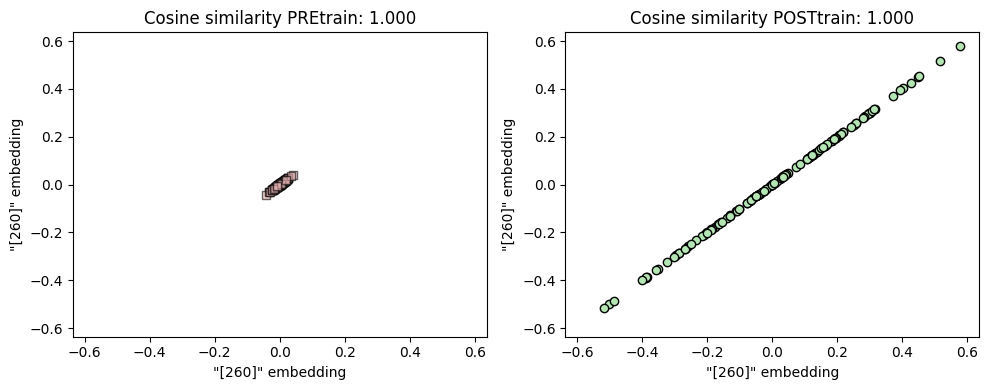

In [22]:
import torch.nn.functional as F
# compare specific token embeddings


timeTid = tokzer.encode(" the")
machineTid = tokzer.encode(" the")
print(timeTid[0], machineTid[0])

timeE_pre = pre_train_embs[timeTid[0]]
machineE_pre = pre_train_embs[machineTid[0]]
print("S ", machineE_pre.shape, "US 0", machineE_pre.unsqueeze(0).shape, "US1", machineE_pre.unsqueeze(1).shape)


timeE_post = post_train_embs[timeTid[0]]
machineE_post = post_train_embs[machineTid[0]]

# print(pre_train_embs == post_train_embs)

simPost = np.dot(timeE_post.detach().numpy(), machineE_post.detach().numpy()) / (np.linalg.norm(timeE_post.detach().numpy()) * np.linalg.norm(machineE_post.detach().numpy()))
simPre = np.dot(timeE_pre.detach().numpy(), machineE_pre.detach().numpy()) / (np.linalg.norm(timeE_pre.detach().numpy()) * np.linalg.norm(machineE_pre.detach().numpy()))

simPostM = np.dot(timeE_post.detach().numpy(), machineE_post.detach().numpy()) / np.sqrt(torch.sum(timeE_post**2).detach().numpy() * torch.sum(machineE_post**2).detach().numpy())
simPreM = np.dot(timeE_pre.detach().numpy(), machineE_pre.detach().numpy()) / np.sqrt(torch.sum(timeE_pre**2).detach().numpy() * torch.sum(machineE_pre**2).detach().numpy())

simPostT = F.cosine_similarity(timeE_post.unsqueeze(0), machineE_post.unsqueeze(0), dim=1)
simPreT = F.cosine_similarity(timeE_pre.unsqueeze(0), machineE_pre.unsqueeze(0), dim=1)


print("NP sim (post,pre)", simPost, simPre)
print("Manual sim (post,pre)", simPostM, simPreM)
print("Tensor sim (post,pre)", simPostT, simPreT)
# -0.031703003 -0.031791743

# vizualize
_,axs = plt.subplots(1,2,figsize=(10,4))

axlim = torch.cat((abs(timeE_pre),abs(machineE_pre),abs(timeE_post),abs(machineE_post))).max() * 1.1
axs[0].plot(timeE_pre,machineE_pre,'ks',markerfacecolor=[.9,.7,.7],alpha=.6)
axs[0].set(xlim=[-axlim,axlim],ylim=[-axlim,axlim],xlabel=f'"{timeTid}" embedding',
           ylabel=f'"{machineTid}" embedding',title=f'Cosine similarity PREtrain: {simPre:.3f}')

axs[1].plot(timeE_post,machineE_post,'ko',markerfacecolor=[.7,.9,.7])
axs[1].set(xlim=[-axlim,axlim],ylim=[-axlim,axlim],xlabel=f'"{timeTid}" embedding',
           ylabel=f'"{machineTid}" embedding',title=f'Cosine similarity POSTtrain: {simPost:.3f}')

plt.tight_layout()
plt.show()



In [27]:
# Proof that 
# softmax = e^log_softmax

x = torch.tensor([0.1, 0.2])
lsf = torch.log_softmax(x, dim=0)
sf = torch.softmax(x, dim=0)
print("Log softmax ", lsf)
print("Soft max", sf)

ds = lsf.exp()
print("e^log_softmax ", ds)

# d = lsf.exp()/lsf.exp().sum()


Log softmax  tensor([-0.7444, -0.6444])
Soft max tensor([0.4750, 0.5250])
e^log_softmax  tensor([0.4750, 0.5250])


In [26]:
# faltten example
xx = torch.randn(4,4)
print("Orig ", xx.shape)

print("Flattned ", xx.flatten().shape)

cc = torch.tensor([1,3,4,5])
print(torch.diff(cc, n=1))
print(torch.diff(cc, n=2))

Orig  torch.Size([4, 4])
Flattned  torch.Size([16])
tensor([2, 1, 1])
tensor([-1,  0])
